In [1]:
# %% [markdown]
# # Textile Defect Detection (Kaggle TextileDefectDetection) - Clean Baseline
# This notebook keeps the original pipeline and paths, but is reorganized for clarity.
#
# Pipeline:
# 1) Merge raw train/test CSV + H5 into a single processed dataset
# 2) Compute MD5 hashes to analyze exact duplicates / leakage
# 3) Deduplicate within each original split, then stratified Train/Val split
# 4) Train a small CNN classifier with Early Stopping


In [2]:
import copy
import hashlib
import json
import math
import os
import random
from collections import defaultdict
from pathlib import Path
from typing import Any, Callable, Dict, Iterator, List, Optional, Tuple, cast

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import tqdm
from sklearn.metrics import ConfusionMatrixDisplay, average_precision_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    import torchinfo
except ImportError:
    torchinfo = None

try:
    import torch_directml  # type: ignore
except ImportError:
    torch_directml = None

try:
    from captum.attr import IntegratedGradients
    from captum.attr import visualization as viz
except ImportError:
    IntegratedGradients = None
    viz = None


In [3]:
# %% [markdown]
# ## 1. Imports & Configuration

# Disable HDF5 file locking for better compatibility
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

# Path configuration (DO NOT CHANGE)
ROOT = Path.cwd()
RAW = ROOT / "data" / "raw" / "textile"
PROCESSED = ROOT / "data" / "processed"
PROCESSED.mkdir(parents=True, exist_ok=True)

# File paths (DO NOT CHANGE)
TRAIN_H5, TRAIN_CSV = RAW / "train64.h5", RAW / "train64.csv"
TEST_H5, TEST_CSV = RAW / "test64.h5", RAW / "test64.csv"
OUT_H5, OUT_CSV = PROCESSED / "full64.h5", PROCESSED / "full64.csv"
TRAIN_SPLIT_CSV = PROCESSED / "train_split.csv"
VAL_SPLIT_CSV = PROCESSED / "val_split.csv"
TEST_SPLIT_CSV = PROCESSED / "test_split.csv"


# Set True to force NVIDIA CUDA. If CUDA is unavailable, raise an actionable error.
REQUIRE_CUDA = True


def _torch_cuda_version() -> Optional[str]:
    version_module = getattr(torch, "version", None)
    return cast(Optional[str], getattr(version_module, "cuda", None))


def _print_torch_runtime() -> None:
    cuda_version = _torch_cuda_version()
    print(f"[Runtime] torch={torch.__version__}")
    print(f"[Runtime] torch.version.cuda={cuda_version}")
    print(f"[Runtime] cuda.is_available={torch.cuda.is_available()}")
    print(f"[Runtime] cuda.device_count={torch.cuda.device_count()}")


def select_device(require_cuda: bool = False):
    '''
    Priority:
    1) NVIDIA CUDA
    2) DirectML (Windows AMD/Intel/NVIDIA)
    3) Apple MPS
    4) CPU
    '''
    if torch.cuda.is_available() and torch.cuda.device_count() > 0:
        gpu_name = torch.cuda.get_device_name(0)
        return torch.device("cuda"), f"cuda ({gpu_name})"

    if require_cuda:
        cuda_version = _torch_cuda_version()
        if cuda_version is None:
            reason = (
                "Detected CPU-only PyTorch build. "
                "Install CUDA-enabled PyTorch in this kernel environment."
            )
        else:
            reason = "CUDA build detected, but no usable CUDA device is visible to PyTorch."
        raise RuntimeError(
            "REQUIRE_CUDA=True but CUDA is unavailable.\n"
            f"Reason: {reason}\n"
            "Quick fix (conda): conda install pytorch torchvision pytorch-cuda=12.4 -c pytorch -c nvidia"
        )

    if torch_directml is not None:
        try:
            dml_runtime = cast(Any, torch_directml)
            dml_device = dml_runtime.device()
            return dml_device, "directml (AMD/Intel/NVIDIA)"
        except Exception as e:
            print(f"[WARN] DirectML detected but unavailable: {e}")

    if hasattr(torch, "backends") and hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps"), "mps (Apple Silicon)"

    return torch.device("cpu"), "cpu"


_print_torch_runtime()
device, device_name = select_device(require_cuda=REQUIRE_CUDA)
print(f"Using device: {device_name}")


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(42)


def _require_file(path: Path) -> None:
    '''Fail fast when a required file is missing.'''
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}")


def _normalize_label(x) -> str:
    return str(x).strip()


def print_class_counts(df: pd.DataFrame, title: str) -> None:
    '''Print total rows and per-class distribution for the given dataframe.'''
    if "indication_type" not in df.columns:
        print(f"[{title}] Missing column: indication_type")
        return

    vc = df["indication_type"].astype(str).str.strip().value_counts()
    print(f"\n[{title}] total_images={len(df)}")
    for k, v in vc.items():
        print(f"  {k}: {v}")


[Runtime] torch=2.5.1
[Runtime] torch.version.cuda=12.4
[Runtime] cuda.is_available=True
[Runtime] cuda.device_count=1
Using device: cuda (NVIDIA GeForce RTX 3060 Ti)


In [4]:
# %% [markdown]
# ## 1.5 Global Training Configuration
# Shared settings for all models (Baseline CNN + ResNet + future models)

FULL_CLASSES = ["good", "color", "cut", "hole", "thread", "metal_contamination"]

TRAIN_CFG = {
    "batch": 512,
    "epochs": 30,
    "patience": 5,
}

# %% [markdown]
# ## 1.52 Global Optimizer Configuration
# Optimizer hyperparameters shared by Baseline CNN and ResNet experiments.
OPTIM_CFG = {
    "name": "adam",
    "lr": 0.001,
    "foreach": False,
}

BASELINE_SCENARIO = "all_training"

# %% [markdown]
# ## 1.55 Global Evaluation Configuration
# Shared validation metrics and early-stopping target for all models.
EVAL_CFG = {
    "f1_average": "macro",
    "auprc_average": "macro",
    "zero_division": 0,
    "early_stop_metric": "f1",
    "early_stop_mode": "max",
}


In [5]:
# %% [markdown]
# ## 1.6 Global Split Scenarios (Reusable)
# One shared split table used by all models.

SPLIT_SCENARIOS = {
    # 1) Use all training data
    "all_training": {
        "defect_classes": FULL_CLASSES,
        "train_size": 47843,
        "defect_frac": 0.0,
        "desc": "Use all available deduplicated training data",
    },
    # 2) 50/50: 50% good + 50% defects (defect classes balanced)
    "fifty_fifty": {
        "defect_classes": FULL_CLASSES,
        "train_size": 20000,
        "defect_frac": 0.10,
        "desc": "50% good + 50% defects (evenly distributed across defect classes)",
    },
    # 3) Excluding two classes
    "exclude_two_classes": {
        "defect_classes": ["good", "color", "cut", "hole"],
        "train_size": 20000,
        "defect_frac": 0.0,
        "desc": "Train without two classes: thread, metal_contamination",
    },
    # 4) Imbalanced dataset
    "imbalanced": {
        "defect_classes": FULL_CLASSES,
        "train_size": 20000,
        "defect_frac": 0.02,
        "desc": "Strong class imbalance toward good samples",
    },
}

# Baseline CNN uses scenario #1.
BASELINE_SPLIT_CFG = SPLIT_SCENARIOS[BASELINE_SCENARIO]

for name, split_cfg in SPLIT_SCENARIOS.items():
    print(f"{name}: {split_cfg['desc']}")


all_training: Use all available deduplicated training data
fifty_fifty: 50% good + 50% defects (evenly distributed across defect classes)
exclude_two_classes: Train without two classes: thread, metal_contamination
imbalanced: Strong class imbalance toward good samples


In [6]:
# %% [markdown]
# ## 2. Merge Raw Train/Test into Processed Full Dataset

def merge_data() -> None:
    """
    Merge separate train/test H5 and CSV files into a unified dataset.

    Outputs:
      - data/processed/full64.csv
      - data/processed/full64.h5
    """
    if OUT_H5.exists() and OUT_CSV.exists():
        print("Dataset already merged. Skipping merge.")
        return

    _require_file(TRAIN_CSV)
    _require_file(TEST_CSV)
    _require_file(TRAIN_H5)
    _require_file(TEST_H5)

    df_train = pd.read_csv(TRAIN_CSV)
    df_test = pd.read_csv(TEST_CSV)

    # Keep original split info
    df_train["original_split"] = "train"
    df_test["original_split"] = "test"

    full_df = pd.concat([df_train, df_test], ignore_index=True)
    full_df.to_csv(OUT_CSV, index=False)
    print(f"Saved merged CSV: {OUT_CSV}")

    with h5py.File(OUT_H5, "w") as f_out:
        with h5py.File(TRAIN_H5, "r") as f_tr, h5py.File(TEST_H5, "r") as f_te:
            tr_imgs = f_tr["images"]
            te_imgs = f_te["images"]

            total_shape = (tr_imgs.shape[0] + te_imgs.shape[0], *tr_imgs.shape[1:])
            dset = f_out.create_dataset("images", shape=total_shape, dtype="f")  # keep original dtype choice

            dset[: tr_imgs.shape[0]] = tr_imgs[:]
            dset[tr_imgs.shape[0] :] = te_imgs[:]

    print(f"Saved merged H5: {OUT_H5}")


In [7]:
# %% [markdown]
# ## 3. MD5 Hashing & Duplicate Analysis

def get_h5_hashes(h5_path: Path, total_images: int, chunk_size: int = 5000) -> List[str]:
    """Generate MD5 fingerprints for all images in the H5 file."""
    hashes: List[str] = [""] * total_images
    print(f"Generating MD5 fingerprints for {total_images} images...")

    with h5py.File(h5_path, "r") as f:
        images = f["images"]
        for start in range(0, total_images, chunk_size):
            end = min(start + chunk_size, total_images)
            chunk = images[start:end]
            for i, img in enumerate(chunk):
                hashes[start + i] = hashlib.md5(img.tobytes()).hexdigest()

    return hashes


def analyze_duplicates() -> List[str]:
    """
    Identify exact duplicates via MD5 and check leakage across original splits.

    Output:
      - data/processed/duplicates_report.csv (if duplicates exist)
    """
    _require_file(OUT_CSV)
    _require_file(OUT_H5)

    df = pd.read_csv(OUT_CSV)
    with h5py.File(OUT_H5, "r") as f:
        total = int(f["images"].shape[0])

    all_hashes = get_h5_hashes(OUT_H5, total)

    hash_map: Dict[str, List[int]] = defaultdict(list)
    for idx, h in enumerate(all_hashes):
        hash_map[h].append(idx)

    dup_groups = {h: idxs for h, idxs in hash_map.items() if len(idxs) > 1}
    dup_rows = sum(len(idxs) for idxs in dup_groups.values())

    print(f"Duplicate groups={len(dup_groups)} | duplicate_rows={dup_rows}")

    if dup_groups:
        dup_indices = [i for idxs in dup_groups.values() for i in idxs]
        report_df = df.iloc[dup_indices].copy()
        report_df["md5"] = [all_hashes[i] for i in dup_indices]
        report_path = PROCESSED / "duplicates_report.csv"
        report_df.to_csv(report_path, index=False)
        print(f"Saved duplicates report: {report_path}")

        # Leakage check: same md5 appears in both original train and original test
        leakage = report_df.groupby("md5")["original_split"].nunique()
        if (leakage > 1).any():
            print("[WARNING] Data leakage detected across original splits (train/test)!")
        else:
            print("[SAFE] No leakage found among duplicates across original splits.")

    return all_hashes


In [8]:
# %% [markdown]
# ## 4. Split Generation (Dedup per original split + Stratified Train/Val)

def create_clean_split(all_hashes: List[str], included_classes: List[str], train_size: int, defect_frac: float) -> None:
    """
    Remove internal duplicates within each original split and generate Train/Val/Test CSVs.
    Remove requested classes from training set before splitting into final train and validation sets.

    Outputs:
      - data/processed/train_split.csv
      - data/processed/val_split.csv
      - data/processed/test_split.csv
    """
    df = pd.read_csv(OUT_CSV).copy()
    df["abs_ptr"] = range(len(df))  # pointer into full64.h5
    df["md5"] = all_hashes
    df["indication_type"] = df["indication_type"].astype(str).str.strip()

    tr_df_raw = df[df["original_split"] == "train"].copy()
    te_df_raw = df[df["original_split"] == "test"].copy()

    # Deduplicate within each portion
    tr_before, te_before = len(tr_df_raw), len(te_df_raw)
    tr_df = tr_df_raw.drop_duplicates(subset="md5", keep="first")
    te_df = te_df_raw.drop_duplicates(subset="md5", keep="first")
    tr_removed, te_removed = tr_before - len(tr_df), te_before - len(te_df)
    total_removed = tr_removed + te_removed

    print(f"Duplicates removed (within split): train={tr_removed}, test={te_removed}, total={total_removed}")

    # Keep only requested classes in training dataframe
    tr_df = tr_df[tr_df["indication_type"].isin(included_classes)].copy()

    # Sample desired fraction profile
    reduced_tr_df = reduce_training_set(tr_df, included_classes, train_size, defect_frac)
    reduced_tr_df = reduced_tr_df.sample(frac=1, random_state=42).reset_index(drop=True)

    split_col = "index" if "index" in reduced_tr_df.columns else "abs_ptr"

    # Stratified split (Train -> Train/Val) on unique sample key
    unique_df = reduced_tr_df.drop_duplicates(split_col)[[split_col, "indication_type"]].copy()
    label_counts = unique_df["indication_type"].value_counts()
    use_stratify = (label_counts.min() >= 2) and (label_counts.shape[0] > 1)
    stratify_labels = unique_df["indication_type"] if use_stratify else None
    if not use_stratify:
        print("[WARN] Stratified split disabled (insufficient per-class samples).")

    train_idx, val_idx = train_test_split(
        unique_df[split_col],
        test_size=0.1,
        random_state=42,
        stratify=stratify_labels,
    )

    df_train = reduced_tr_df[reduced_tr_df[split_col].isin(train_idx)].sample(frac=1, random_state=42)
    df_val = reduced_tr_df[reduced_tr_df[split_col].isin(val_idx)].sample(frac=1, random_state=42)

    train_path = TRAIN_SPLIT_CSV
    val_path = VAL_SPLIT_CSV
    test_path = TEST_SPLIT_CSV

    df_train.to_csv(train_path, index=False)
    df_val.to_csv(val_path, index=False)
    te_df.to_csv(test_path, index=False)

    print(f"Datasets finalized: Train({len(df_train)}), Val({len(df_val)}), Test({len(te_df)})")

    # Requested reporting
    print_class_counts(df, "FULL (merged)")
    print_class_counts(tr_df_raw, "ORIG TRAIN (raw)")
    print_class_counts(te_df_raw, "ORIG TEST (raw)")
    print_class_counts(tr_df, "ORIG TRAIN (deduped)")
    print_class_counts(te_df, "ORIG TEST (deduped)")
    print_class_counts(df_train, "TRAIN SPLIT")
    print_class_counts(df_val, "VAL SPLIT")
    print_class_counts(te_df, "TEST SPLIT")


def reduce_training_set(dedup_df, included_classes: List[str], training_size: int, defect_frac: float):
    # Use all deduplicated rows when defect_frac is 0.
    if defect_frac == 0:
        return dedup_df

    if len(included_classes) < 2:
        n = min(training_size, len(dedup_df))
        return dedup_df.sample(n=n, random_state=42)

    # defect_frac means per-defect-class fraction w.r.t. training_size
    num_defect_samples = math.floor(training_size * defect_frac)
    num_good_samples = training_size - num_defect_samples * (len(included_classes) - 1)

    if num_good_samples <= 0:
        raise ValueError(
            "Invalid training_size/defect_frac combination: non-positive good sample count. "
            f"training_size={training_size}, defect_frac={defect_frac}, classes={len(included_classes)}"
        )

    sampled_parts = []

    # sample defects
    for cls_name in included_classes[1:]:
        holder_df = dedup_df.loc[dedup_df["indication_type"] == cls_name]
        n = min(num_defect_samples, len(holder_df))
        if n < num_defect_samples:
            print(f"[WARN] class={cls_name}: requested {num_defect_samples}, available {len(holder_df)}, using {n}")
        if n > 0:
            sampled_parts.append(holder_df.sample(n=n, random_state=42))

    # sample good
    good_df = dedup_df.loc[dedup_df["indication_type"] == included_classes[0]]
    n_good = min(num_good_samples, len(good_df))
    if n_good < num_good_samples:
        print(f"[WARN] class={included_classes[0]}: requested {num_good_samples}, available {len(good_df)}, using {n_good}")
    if n_good > 0:
        sampled_parts.append(good_df.sample(n=n_good, random_state=42))

    if not sampled_parts:
        raise ValueError("No samples selected. Please adjust training_size/defect_frac.")

    reduced_df = pd.concat(sampled_parts, ignore_index=True)
    return reduced_df


In [9]:
## %% [markdown]
# ## 5. Label Map

LABEL_MAP_JSON = PROCESSED / "label_map.json"
EXPECTED_CLASSES = list(FULL_CLASSES)


def _validate_labels(observed: List[str], label_map: Dict[str, int]) -> None:
    unknown = sorted(set(observed) - set(label_map.keys()))
    if unknown:
        raise ValueError(
            "CSV contains unknown class names (not in label_map).\n"
            f"unknown_labels={unknown}\n"
            f"label_map_keys={sorted(label_map.keys())}"
        )


def build_label_map_from_full_csv(full_csv_path: Path) -> Dict[str, int]:
    '''
    Build a stable label map from labels present in the provided CSV.
    Order always follows EXPECTED_CLASSES.
    '''
    df = pd.read_csv(full_csv_path)
    observed = set(df["indication_type"].astype(str).str.strip().unique().tolist())

    unknown = sorted(observed - set(EXPECTED_CLASSES))
    if unknown:
        raise ValueError(
            "CSV contains labels outside EXPECTED_CLASSES.\n"
            f"unknown={unknown}\n"
            f"expected={EXPECTED_CLASSES}"
        )

    ordered_present = [name for name in EXPECTED_CLASSES if name in observed]
    if not ordered_present:
        raise ValueError("No valid labels found in CSV.")

    return {name: i for i, name in enumerate(ordered_present)}


def load_or_create_label_map(PASSED_PATH: Path) -> Dict[str, int]:
    label_map = build_label_map_from_full_csv(PASSED_PATH)
    LABEL_MAP_JSON.write_text(
        json.dumps(label_map, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    return label_map


def validate_split_labels(csv_path: Path, label_map: Dict[str, int]) -> None:
    df = pd.read_csv(csv_path)
    observed = df["indication_type"].astype(str).str.strip().unique().tolist()
    _validate_labels([_normalize_label(x) for x in observed], label_map)


def validate_common_splits(label_map: Dict[str, int], include_test: bool = True) -> None:
    validate_split_labels(TRAIN_SPLIT_CSV, label_map)
    validate_split_labels(VAL_SPLIT_CSV, label_map)
    if include_test:
        validate_split_labels(TEST_SPLIT_CSV, label_map)


def make_split_datasets_and_loaders(label_map: Dict[str, int], batch_size: int):
    train_ds = TextileDataset(TRAIN_SPLIT_CSV, OUT_H5, label_map=label_map)
    val_ds = TextileDataset(VAL_SPLIT_CSV, OUT_H5, label_map=label_map)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size)
    return train_ds, val_ds, train_loader, val_loader


In [10]:
# %% [markdown]
# ## 6. PyTorch Dataset & Model

class TextileDataset(Dataset[Tuple[torch.Tensor, torch.Tensor]]):
    """Read images from full64.h5 using pointers stored in the split CSV."""

    def __init__(
        self,
        csv_path: Path,
        h5_path: Path,
        *,
        label_map: Optional[Dict[str, int]] = None,
        transform: Optional[Callable[[torch.Tensor], torch.Tensor]] = None,
        strict_labels: bool = True,
    ):
        self.df = pd.read_csv(csv_path)
        self.h5_path = str(h5_path)
        self.transform = transform

        if "abs_ptr" not in self.df.columns:
            raise ValueError(
                "CSV missing abs_ptr. Please use create_clean_split() outputs: train_split.csv/val_split.csv/test_split.csv."
            )
        if "indication_type" not in self.df.columns:
            raise ValueError("CSV missing indication_type.")

        if label_map is None:
            raise ValueError(
                "label_map is required. Call load_or_create_label_map() then pass it into TextileDataset(..., label_map=label_map)."
            )
        self.label_map = dict(label_map)

        labels = [_normalize_label(x) for x in self.df["indication_type"].tolist()]
        if strict_labels:
            _validate_labels(labels, self.label_map)
        self.df["indication_type"] = labels

    def __len__(self) -> int:
        return len(self.df)

    def __iter__(self) -> Iterator[Tuple[torch.Tensor, torch.Tensor]]:
        for idx in range(len(self)):
            yield self[idx]

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        row = self.df.iloc[idx]
        abs_ptr = int(row["abs_ptr"])

        with h5py.File(self.h5_path, "r") as f:
            img = f["images"][abs_ptr]

        img_t = torch.from_numpy(img).float()
        if img_t.max() > 1.0:
            img_t /= 255.0

        # Ensure channel-first (1, H, W)
        if img_t.ndim == 2:
            img_t = img_t.unsqueeze(0)
        elif img_t.ndim == 3 and img_t.shape[-1] == 1:
            img_t = img_t.permute(2, 0, 1)

        if self.transform is not None:
            img_t = self.transform(img_t)

        label = self.label_map[row["indication_type"]]
        return img_t, torch.tensor(label, dtype=torch.long)


class TextileBaselineCNN(nn.Module):
    """Small CNN baseline for 64x64 grayscale images."""

    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(x))


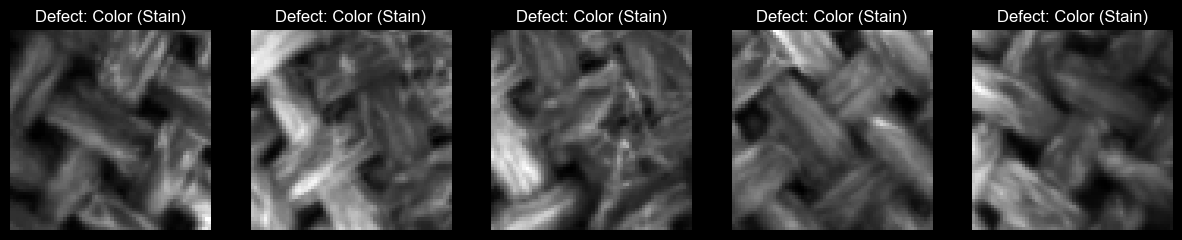

In [11]:
# %% [markdown]
# ## 6.5 Quick Visualization (Color Defect Samples)

def visualize_color_defects(dataset, label_map, num_samples=5):
    # Find the integer index for the 'color' class
    if "color" not in label_map:
        print("[INFO] 'color' class is not in current label_map. Skipping visualization.")
        return
    color_idx = label_map["color"]

    fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))
    if num_samples == 1:
        axes = [axes]

    found = 0
    for img, label in dataset:
        label_val = int(label.item()) if torch.is_tensor(label) else int(label)
        if label_val == color_idx:
            # Reshape from (1, 64, 64) to (64, 64) for plotting
            axes[found].imshow(img.squeeze(), cmap="gray")
            axes[found].set_title("Defect: Color (Stain)")
            axes[found].axis("off")
            found += 1
        if found == num_samples:
            break

    if found < num_samples:
        print(f"Only found {found} color samples.")
    plt.show()


# Optional quick demo: safe to run before/after training cells.
train_split_csv = TRAIN_SPLIT_CSV
if train_split_csv.exists():
    demo_label_map = load_or_create_label_map(train_split_csv)
    demo_train_ds = TextileDataset(train_split_csv, OUT_H5, label_map=demo_label_map)
    visualize_color_defects(demo_train_ds, demo_label_map)
else:
    print("[INFO] train_split.csv not found yet. Run split-generation/training cells first, then rerun this cell.")


In [12]:
# %% [markdown]
# ## 7. Training Utilities (Early Stopping)

class EarlyStopping:
    def __init__(
        self,
        patience: int = 5,
        verbose: bool = True,
        mode: str = "min",
        metric_name: str = "metric",
        min_delta: float = 0.0,
    ):
        if mode not in {"min", "max"}:
            raise ValueError("mode must be either 'min' or 'max'")
        self.patience = patience
        self.verbose = verbose
        self.mode = mode
        self.metric_name = metric_name
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = float("inf") if mode == "min" else -float("inf")
        self.early_stop = False
        self.best_model_state = None

    def _is_improvement(self, score: float) -> bool:
        if self.mode == "min":
            return score < (self.best_score - self.min_delta)
        return score > (self.best_score + self.min_delta)

    def __call__(self, score: float, model: nn.Module) -> None:
        if self._is_improvement(score):
            self.best_score = score
            self.best_model_state = copy.deepcopy(model.state_dict())
            self.counter = 0
            if self.verbose:
                print(f"Validation {self.metric_name} improved. Saving model weights.")
        else:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter} of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True


def _compute_eval_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_prob: np.ndarray,
    num_classes: int,
) -> Dict[str, float]:
    acc = 100.0 * float((y_pred == y_true).sum()) / max(len(y_true), 1)
    f1 = f1_score(
        y_true,
        y_pred,
        labels=list(range(num_classes)),
        average=EVAL_CFG["f1_average"],
        zero_division=EVAL_CFG["zero_division"],
    )

    y_true_bin = np.zeros((len(y_true), num_classes), dtype=np.int64)
    y_true_bin[np.arange(len(y_true)), y_true] = 1
    try:
        auprc = average_precision_score(y_true_bin, y_prob, average=EVAL_CFG["auprc_average"])
    except ValueError:
        auprc = float("nan")

    return {"accuracy": acc, "f1": float(f1), "auprc": float(auprc)}


def _metric_to_str(v: float, digits: int = 4) -> str:
    if np.isnan(v):
        return "nan"
    return f"{v:.{digits}f}"


def run_step(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    device: torch.device,
    is_train: bool = True,
) -> Tuple[float, Dict[str, float]]:
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_true: List[np.ndarray] = []
    all_pred: List[np.ndarray] = []
    all_prob: List[np.ndarray] = []

    with torch.set_grad_enabled(is_train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1)

            total_loss += float(loss.item())
            all_true.append(labels.detach().cpu().numpy())
            all_pred.append(preds.detach().cpu().numpy())
            all_prob.append(probs.detach().cpu().numpy())

    avg_loss = total_loss / max(len(loader), 1)
    if not all_true:
        return avg_loss, {"accuracy": 0.0, "f1": 0.0, "auprc": float("nan")}

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)
    y_prob = np.concatenate(all_prob)
    num_classes = int(y_prob.shape[1])
    metrics = _compute_eval_metrics(y_true, y_pred, y_prob, num_classes)
    return avg_loss, metrics


In [13]:
# %% [markdown]
# ## 8. Main (Baseline CNN)
# This section uses shared settings from TRAIN_CFG and scenario `all_training`.


In [14]:
# Step 1: Build processed dataset and baseline split files
merge_data()
hashes = analyze_duplicates()
create_clean_split(hashes, BASELINE_SPLIT_CFG["defect_classes"], BASELINE_SPLIT_CFG["train_size"], BASELINE_SPLIT_CFG["defect_frac"])


Dataset already merged. Skipping merge.
Generating MD5 fingerprints for 96000 images...
Duplicate groups=391 | duplicate_rows=782
Saved duplicates report: E:\Download\Pycharm\CHE1148_Defect_Detecting\data\processed\duplicates_report.csv
[SAFE] No leakage found among duplicates across original splits.
Duplicates removed (within split): train=157, test=234, total=391
Datasets finalized: Train(43058), Val(4785), Test(47766)

[FULL (merged)] total_images=96000
  good: 16000
  color: 16000
  cut: 16000
  hole: 16000
  metal_contamination: 16000
  thread: 16000

[ORIG TRAIN (raw)] total_images=48000
  good: 8000
  color: 8000
  cut: 8000
  hole: 8000
  metal_contamination: 8000
  thread: 8000

[ORIG TEST (raw)] total_images=48000
  good: 8000
  color: 8000
  cut: 8000
  hole: 8000
  metal_contamination: 8000
  thread: 8000

[ORIG TRAIN (deduped)] total_images=47843
  good: 8000
  color: 7991
  cut: 7991
  hole: 7980
  thread: 7956
  metal_contamination: 7925

[ORIG TEST (deduped)] total_imag

In [15]:
# Step 2: Build and validate label map for baseline split
label_map = load_or_create_label_map(OUT_CSV)
validate_common_splits(label_map, include_test=True)
print("\nlabel_map:", label_map)



label_map: {'good': 0, 'color': 1, 'cut': 2, 'hole': 3, 'thread': 4, 'metal_contamination': 5}


In [16]:
# Step 3: Create datasets and dataloaders
train_ds, val_ds, train_loader, val_loader = make_split_datasets_and_loaders(label_map, TRAIN_CFG["batch"])


In [17]:
# Step 4: Initialize baseline CNN training components
model = TextileBaselineCNN(num_classes=len(label_map)).to(device)

print("Baseline CNN Model Summary for Textile Defect Detection:")
if torchinfo is not None:
    summary_obj = torchinfo.summary(
        model,
        input_size=(TRAIN_CFG["batch"], 1, 64, 64),
        col_names=["input_size", "output_size", "num_params", "kernel_size"],
        verbose=0,
    )
    print(summary_obj)
else:
    print("[INFO] torchinfo not installed. Printing nn.Module structure instead.")
    print(model)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=OPTIM_CFG["lr"], foreach=OPTIM_CFG["foreach"])
early_stop = EarlyStopping(
    patience=TRAIN_CFG["patience"],
    verbose=True,
    mode=EVAL_CFG["early_stop_mode"],
    metric_name=EVAL_CFG["early_stop_metric"],
)


Baseline CNN Model Summary for Textile Defect Detection:
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Kernel Shape
TextileBaselineCNN                       [256, 1, 64, 64]          [256, 6]                  --                        --
├─Sequential: 1-1                        [256, 1, 64, 64]          [256, 128, 8, 8]          --                        --
│    └─Conv2d: 2-1                       [256, 1, 64, 64]          [256, 32, 64, 64]         320                       [3, 3]
│    └─BatchNorm2d: 2-2                  [256, 32, 64, 64]         [256, 32, 64, 64]         64                        --
│    └─ReLU: 2-3                         [256, 32, 64, 64]         [256, 32, 64, 64]         --                        --
│    └─MaxPool2d: 2-4                    [256, 32, 64, 64]         [256, 32, 32, 32]         --                        2
│    └─Conv2d: 2-5                       [256, 32, 32, 32]         [256, 64,

In [18]:
# Step 5: Train baseline CNN and save best checkpoint
print(f"\nStarting training on: {device}")
pbar = tqdm.tqdm(range(TRAIN_CFG["epochs"]), desc="Baseline CNN")
for epoch in pbar:
    t_loss, t_metrics = run_step(model, train_loader, criterion, optimizer, device, True)
    v_loss, v_metrics = run_step(model, val_loader, criterion, optimizer, device, False)

    pbar.set_postfix(
        {
            "val_f1": _metric_to_str(v_metrics["f1"]),
            "val_auprc": _metric_to_str(v_metrics["auprc"]),
            "val_acc": _metric_to_str(v_metrics["accuracy"], digits=2),
        }
    )

    early_stop(v_metrics["f1"], model)
    if early_stop.early_stop:
        print(f"Early stopping triggered at epoch {epoch + 1}")
        model.load_state_dict(early_stop.best_model_state)
        break

torch.save(model.state_dict(), "best_textile_baseline.pth")
print("Training Complete.")



Starting training on: cuda


Baseline CNN:   3%|▎         | 1/30 [00:26<12:43, 26.32s/it, val_f1=0.3569, val_auprc=0.5975, val_acc=43.45]

Validation f1 improved. Saving model weights.


Baseline CNN:   7%|▋         | 2/30 [00:53<12:29, 26.78s/it, val_f1=0.6545, val_auprc=0.7712, val_acc=66.75]

Validation f1 improved. Saving model weights.


...

EarlyStopping counter: 5 of 7


Baseline CNN:  37%|███▋      | 11/30 [05:01<08:50, 27.92s/it, val_f1=0.6281, val_auprc=0.7949, val_acc=65.12]

EarlyStopping counter: 6 of 7


Baseline CNN:  37%|███▋      | 11/30 [05:31<09:32, 30.13s/it, val_f1=0.7923, val_auprc=0.8871, val_acc=80.75]

EarlyStopping counter: 7 of 7
Early stopping triggered at epoch 12
Training Complete.


In [19]:
# %% [markdown]
# ## 9. ResNet Experiments
# This section reuses `SPLIT_SCENARIOS` from Section 1.6.


In [20]:

class TextileResNet(nn.Module):
    def __init__(self, num_classes: int):
        super(TextileResNet, self).__init__()

        # Use ResNet-18 because it is computationally efficient for 64x64 images
        # Training from scratch
        self.model = models.resnet18(weights=None)

        # CHANNEL ADAPTATION
        # Original ResNet-18 conv1: Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        # Change 'in_channels' from 3 (RGB) to 1 (Grayscale)
        self.model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

        # OUTPUT ADAPTATION
        num_ftrs = self.model.fc.in_features
        self.model.fc = nn.Linear(num_ftrs, num_classes)

    def forward(self, x):
        return self.model(x)


In [21]:
# Instantiate a preview ResNet (all-training scenario class count)
label_map_all = load_or_create_label_map(OUT_CSV)
model_preview = TextileResNet(len(label_map_all)).to(device)

print("ResNet-18 Model Summary for Textile Defect Detection:")
if torchinfo is not None:
    summary_obj = torchinfo.summary(
        model_preview,
        input_size=(TRAIN_CFG["batch"], 1, 64, 64),
        col_names=["input_size", "output_size", "num_params", "kernel_size"],
        verbose=0,
    )
    print(summary_obj)
else:
    print("[INFO] torchinfo not installed. Skipping model summary.")


ResNet-18 Model Summary for Textile Defect Detection:
Layer (type:depth-idx)                        Input Shape               Output Shape              Param #                   Kernel Shape
TextileResNet                                 [256, 1, 64, 64]          [256, 6]                  --                        --
├─ResNet: 1-1                                 [256, 1, 64, 64]          [256, 6]                  --                        --
│    └─Conv2d: 2-1                            [256, 1, 64, 64]          [256, 64, 32, 32]         3,136                     [7, 7]
│    └─BatchNorm2d: 2-2                       [256, 64, 32, 32]         [256, 64, 32, 32]         128                       --
│    └─ReLU: 2-3                              [256, 64, 32, 32]         [256, 64, 32, 32]         --                        --
│    └─MaxPool2d: 2-4                         [256, 64, 32, 32]         [256, 64, 16, 16]         --                        3
│    └─Sequential: 2-5                      

In [22]:
def prepare_resnet_split_and_loaders(split_cfg: Dict, train_cfg: Dict):
    create_clean_split(
        hashes,
        split_cfg["defect_classes"],
        split_cfg["train_size"],
        split_cfg["defect_frac"],
    )

    split_label_map = load_or_create_label_map(TRAIN_SPLIT_CSV)
    validate_common_splits(split_label_map, include_test=False)

    split_train_ds, split_val_ds, split_train_loader, split_val_loader = make_split_datasets_and_loaders(
        split_label_map, train_cfg["batch"]
    )

    return split_label_map, split_train_ds, split_val_ds, split_train_loader, split_val_loader


In [23]:
# Run ResNet for all 4 split scenarios
resnet_models = {}
resnet_histories = {}
resnet_label_maps = {}
resnet_loaders = {}

for scenario_name, split_cfg in SPLIT_SCENARIOS.items():
    print(f"\n=== ResNet Scenario: {scenario_name} ===")
    print(split_cfg["desc"])

    split_label_map, split_train_ds, split_val_ds, split_train_loader, split_val_loader = prepare_resnet_split_and_loaders(
        split_cfg, TRAIN_CFG
    )

    model_curr = TextileResNet(num_classes=len(split_label_map)).to(device)
    optimizer_curr = torch.optim.Adam(
        model_curr.parameters(),
        lr=OPTIM_CFG["lr"],
        foreach=OPTIM_CFG["foreach"],
    )
    criterion_curr = nn.CrossEntropyLoss()
    stopper_curr = EarlyStopping(
        patience=TRAIN_CFG["patience"],
        verbose=True,
        mode=EVAL_CFG["early_stop_mode"],
        metric_name=EVAL_CFG["early_stop_metric"],
    )

    history_curr = []
    pbar = tqdm.tqdm(range(TRAIN_CFG["epochs"]), desc=f"ResNet {scenario_name}")
    for epoch in pbar:
        train_loss, train_metrics = run_step(
            model_curr, split_train_loader, criterion_curr, optimizer_curr, device, True
        )
        val_loss, val_metrics = run_step(
            model_curr, split_val_loader, criterion_curr, optimizer_curr, device, False
        )

        history_curr.append(
            {
                "Epoch": epoch + 1,
                "Split": "Train",
                "Loss": train_loss,
                "Accuracy": train_metrics["accuracy"],
                "F1": train_metrics["f1"],
                "AUPRC": train_metrics["auprc"],
            }
        )
        history_curr.append(
            {
                "Epoch": epoch + 1,
                "Split": "Val",
                "Loss": val_loss,
                "Accuracy": val_metrics["accuracy"],
                "F1": val_metrics["f1"],
                "AUPRC": val_metrics["auprc"],
            }
        )
        pbar.set_postfix(
            {
                "val_f1": _metric_to_str(val_metrics["f1"]),
                "val_auprc": _metric_to_str(val_metrics["auprc"]),
                "val_acc": _metric_to_str(val_metrics["accuracy"], digits=2),
            }
        )

        stopper_curr(val_metrics["f1"], model_curr)
        if stopper_curr.early_stop:
            print(f"Early stopping triggered at epoch {epoch + 1}")
            break

    if stopper_curr.best_model_state is not None:
        model_curr.load_state_dict(stopper_curr.best_model_state)

    resnet_models[scenario_name] = model_curr
    resnet_histories[scenario_name] = history_curr
    resnet_label_maps[scenario_name] = split_label_map
    resnet_loaders[scenario_name] = {
        "train_ds": split_train_ds,
        "val_ds": split_val_ds,
        "train_loader": split_train_loader,
        "val_loader": split_val_loader,
    }

    print(f"Completed scenario: {scenario_name}")

# Keep downstream visualization/IG on all-training scenario only
results_resnet = resnet_histories["all_training"]
model_resnet = resnet_models["all_training"]
train_label_map = resnet_label_maps["all_training"]
train_ds = resnet_loaders["all_training"]["train_ds"]
val_loader = resnet_loaders["all_training"]["val_loader"]

print("\nAll ResNet scenarios completed.")
print("results_resnet/model_resnet set to 'all_training' for plot and IG.")



=== ResNet Scenario: all_training ===
Use all available deduplicated training data
Duplicates removed (within split): train=157, test=234, total=391
Datasets finalized: Train(43058), Val(4785), Test(47766)

[FULL (merged)] total_images=96000
  good: 16000
  color: 16000
  cut: 16000
  hole: 16000
  metal_contamination: 16000
  thread: 16000

[ORIG TRAIN (raw)] total_images=48000
  good: 8000
  color: 8000
  cut: 8000
  hole: 8000
  metal_contamination: 8000
  thread: 8000

[ORIG TEST (raw)] total_images=48000
  good: 8000
  color: 8000
  cut: 8000
  hole: 8000
  metal_contamination: 8000
  thread: 8000

[ORIG TRAIN (deduped)] total_images=47843
  good: 8000
  color: 7991
  cut: 7991
  hole: 7980
  thread: 7956
  metal_contamination: 7925

[ORIG TEST (deduped)] total_images=47766
  good: 8000
  cut: 7984
  hole: 7979
  thread: 7974
  color: 7945
  metal_contamination: 7884

[TRAIN SPLIT] total_images=43058
  good: 7200
  cut: 7192
  color: 7192
  hole: 7182
  thread: 7160
  metal_conta

ResNet all_training:   3%|▎         | 1/30 [00:27<13:06, 27.11s/it, val_f1=0.2964, val_auprc=0.5781, val_acc=33.35]

Validation f1 improved. Saving model weights.


ResNet all_training:   7%|▋         | 2/30 [00:56<13:18, 28.50s/it, val_f1=0.5929, val_auprc=0.7776, val_acc=59.39]

Validation f1 improved. Saving model weights.


...

EarlyStopping counter: 5 of 7


ResNet imbalanced:  57%|█████▋    | 17/30 [01:36<01:12,  5.61s/it, val_f1=0.7272, val_auprc=0.7936, val_acc=92.20]

EarlyStopping counter: 6 of 7


ResNet imbalanced:  57%|█████▋    | 17/30 [01:42<01:18,  6.05s/it, val_f1=0.7024, val_auprc=0.7392, val_acc=90.10]

EarlyStopping counter: 7 of 7
Early stopping triggered at epoch 18
Completed scenario: imbalanced

All ResNet scenarios completed.
results_resnet/model_resnet set to 'all_training' for plot and IG.


Saved history plot (.jpg): E:\Download\Pycharm\CHE1148_Defect_Detecting\data\processed\resnet_all_training_metrics.jpg


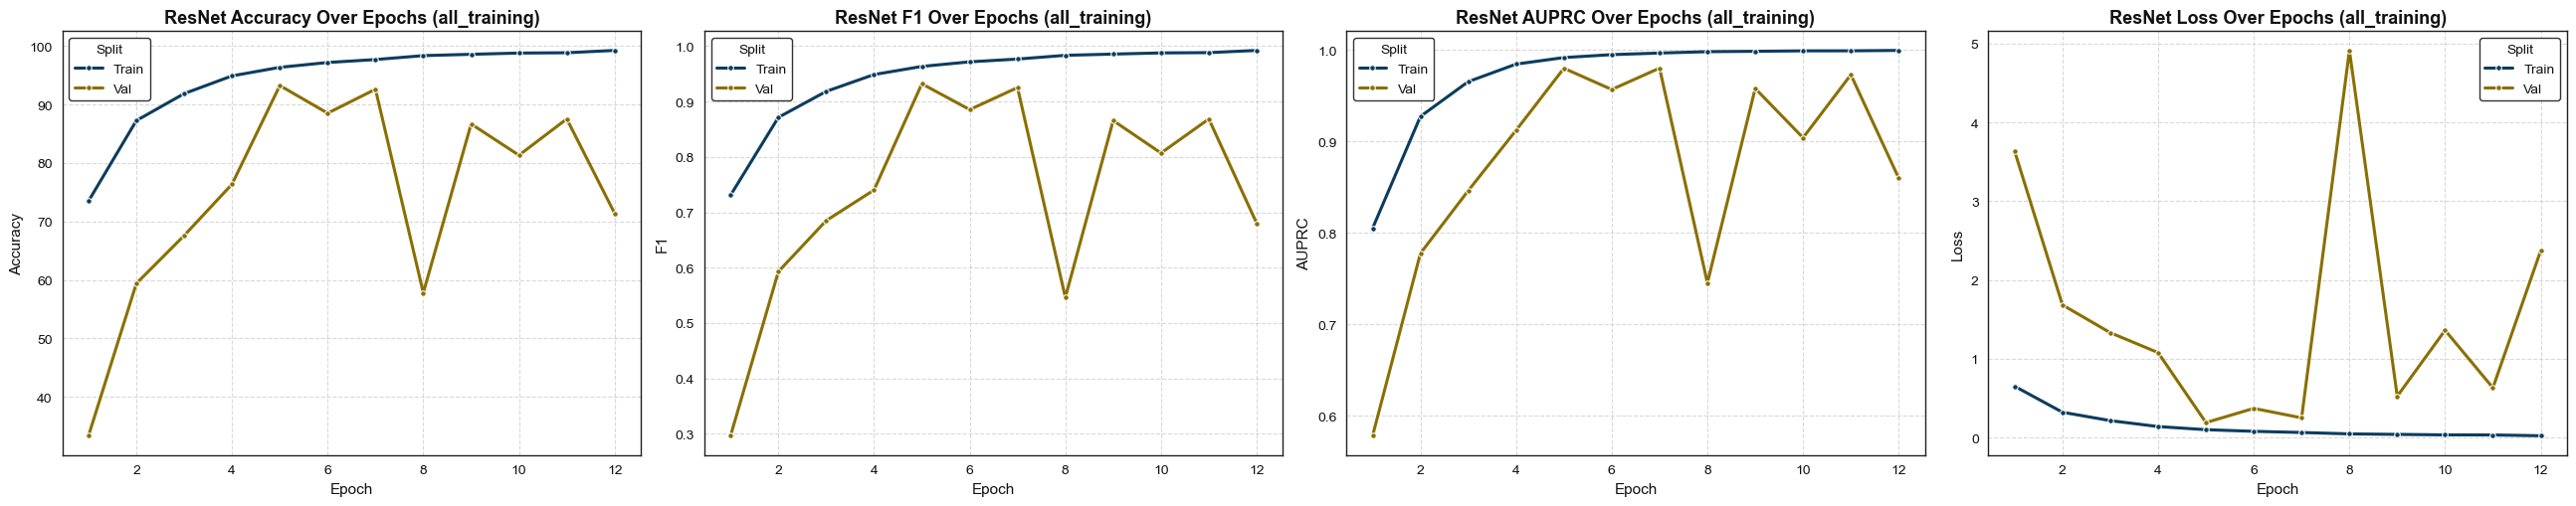

Saved confusion matrix: E:\Download\Pycharm\CHE1148_Defect_Detecting\data\processed\resnet_all_training_confusion.jpg


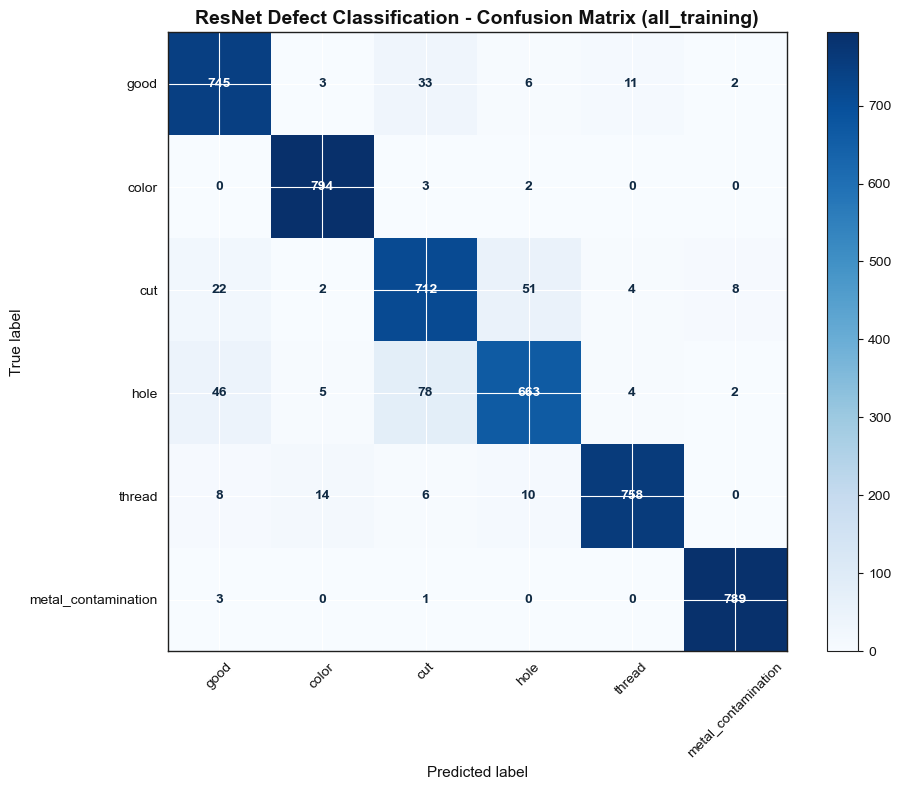

In [26]:
# --- 1. PERFORMANCE PLOT (all_training scenario only) ---
def plot_history(results_list, save_path=None, dpi=280):
    history_df = pd.DataFrame(results_list)
    metrics = [m for m in ["Accuracy", "F1", "AUPRC", "Loss"] if m in history_df.columns]
    if not metrics:
        print("[INFO] No plottable metrics found in history.")
        return

    line_colors = {"Train": "#0b3c5d", "Val": "#8a6f00"}

    with plt.rc_context({
        "figure.facecolor": "#ffffff",
        "axes.facecolor": "#ffffff",
        "savefig.facecolor": "#ffffff",
        "savefig.edgecolor": "#ffffff",
        "savefig.transparent": False,
        "text.color": "#111111",
        "axes.labelcolor": "#111111",
        "axes.edgecolor": "#1f1f1f",
        "xtick.color": "#111111",
        "ytick.color": "#111111",
        "grid.color": "#c6c6c6",
        "grid.alpha": 0.65,
        "grid.linestyle": "--",
    }):
        fig, axes = plt.subplots(1, len(metrics), figsize=(6.5 * len(metrics), 5.2))
        fig.patch.set_facecolor("#ffffff")
        fig.patch.set_alpha(1.0)
        if len(metrics) == 1:
            axes = [axes]

        for i, metric in enumerate(metrics):
            ax = axes[i]
            ax.set_facecolor("#ffffff")
            ax.patch.set_alpha(1.0)
            if sns is not None:
                sns.lineplot(
                    data=history_df,
                    x="Epoch",
                    y=metric,
                    hue="Split",
                    palette=line_colors,
                    ax=ax,
                    linewidth=2.2,
                    marker="o",
                    markersize=4,
                )
            else:
                for split in history_df["Split"].unique():
                    split_df = history_df[history_df["Split"] == split]
                    color = line_colors.get(split, "#333333")
                    ax.plot(split_df["Epoch"], split_df[metric], label=split, linewidth=2.2, marker="o", markersize=4, color=color)
                ax.legend()

            ax.set_title(f"ResNet {metric} Over Epochs (all_training)", fontsize=13, fontweight="bold", color="#111111")
            ax.set_xlabel("Epoch", fontsize=11, color="#111111")
            ax.set_ylabel(metric, fontsize=11, color="#111111")
            ax.tick_params(axis="both", labelsize=10, colors="#111111")
            ax.grid(True, linewidth=0.8)
            for spine in ax.spines.values():
                spine.set_color("#1f1f1f")
                spine.set_linewidth(1.0)
            legend = ax.get_legend()
            if legend is not None:
                legend.set_title("Split")
                legend.get_title().set_color("#111111")
                for text in legend.get_texts():
                    text.set_color("#111111")
                frame = legend.get_frame()
                frame.set_facecolor("#ffffff")
                frame.set_edgecolor("#333333")
                frame.set_alpha(1.0)

        plt.tight_layout()
        if save_path is not None:
            from pathlib import Path
            save_path = Path(save_path)
            if save_path.suffix.lower() not in {".jpg", ".jpeg"}:
                save_path = save_path.with_suffix(".jpg")
            fig.savefig(
                save_path,
                dpi=dpi,
                format="jpeg",
                facecolor="white",
                edgecolor="white",
                transparent=False,
                bbox_inches="tight",
            )
            print(f"Saved history plot (.jpg): {save_path}")
        plt.show()
        plt.close(fig)


# --- 2. THE CONFUSION MATRIX (all_training scenario only) ---
def show_confusion_matrix(model, loader, label_map, device, save_path=None, dpi=220):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            outputs = model(imgs.to(device))
            preds = torch.argmax(outputs, dim=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)
    class_names = list(label_map.keys())

    with plt.rc_context({
        "figure.facecolor": "#ffffff",
        "axes.facecolor": "#ffffff",
        "savefig.facecolor": "#ffffff",
        "savefig.edgecolor": "#ffffff",
        "savefig.transparent": False,
        "text.color": "#111111",
        "axes.labelcolor": "#111111",
        "axes.edgecolor": "#1f1f1f",
        "xtick.color": "#111111",
        "ytick.color": "#111111",
    }):
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
        fig, ax = plt.subplots(figsize=(10, 8))
        fig.patch.set_facecolor("#ffffff")
        fig.patch.set_alpha(1.0)
        ax.set_facecolor("#ffffff")
        ax.patch.set_alpha(1.0)
        disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=True, values_format="d")
        ax.set_title("ResNet Defect Classification - Confusion Matrix (all_training)", fontsize=14, fontweight="bold", color="#111111")
        ax.set_xlabel("Predicted label", fontsize=11, color="#111111")
        ax.set_ylabel("True label", fontsize=11, color="#111111")
        ax.tick_params(axis="both", labelsize=10, colors="#111111")
        for spine in ax.spines.values():
            spine.set_color("#1f1f1f")
            spine.set_linewidth(1.0)

        if disp.im_ is not None and disp.im_.colorbar is not None:
            cbar = disp.im_.colorbar
            cbar.ax.tick_params(colors="#111111")
            cbar.outline.set_edgecolor("#1f1f1f")

        if disp.text_ is not None:
            threshold = cm.max() * 0.60 if cm.size else 0
            for i in range(cm.shape[0]):
                for j in range(cm.shape[1]):
                    txt = disp.text_[i, j]
                    if txt is None:
                        continue
                    txt.set_fontsize(10)
                    txt.set_fontweight("semibold")
                    txt.set_color("white" if cm[i, j] > threshold else "#102a43")

        plt.tight_layout()
        if save_path is not None:
            from pathlib import Path
            save_path = Path(save_path)
            fmt = "jpeg" if save_path.suffix.lower() in {".jpg", ".jpeg"} else None
            fig.savefig(
                save_path,
                dpi=dpi,
                format=fmt,
                facecolor="#ffffff",
                edgecolor="#ffffff",
                transparent=False,
                bbox_inches="tight",
            )
            print(f"Saved confusion matrix: {save_path}")
        plt.show()
        plt.close(fig)


# Auto-run visualization when ResNet outputs are available.
required = {"results_resnet", "model_resnet", "val_loader", "train_label_map", "device"}
if required.issubset(globals()):
    plot_history(results_resnet, save_path=PROCESSED / "resnet_all_training_metrics.jpg")
    show_confusion_matrix(
        model_resnet,
        val_loader,
        train_label_map,
        device,
        save_path=PROCESSED / "resnet_all_training_confusion.jpg",
    )
else:
    print("[INFO] ResNet results not ready. Run the ResNet training cell first.")


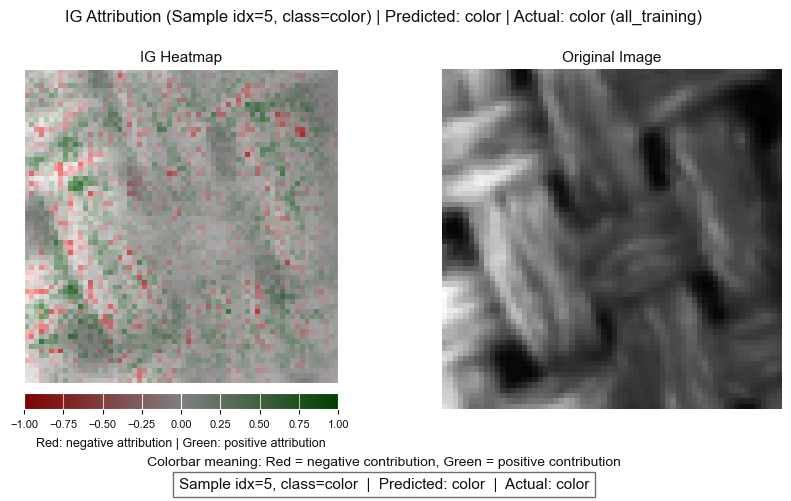

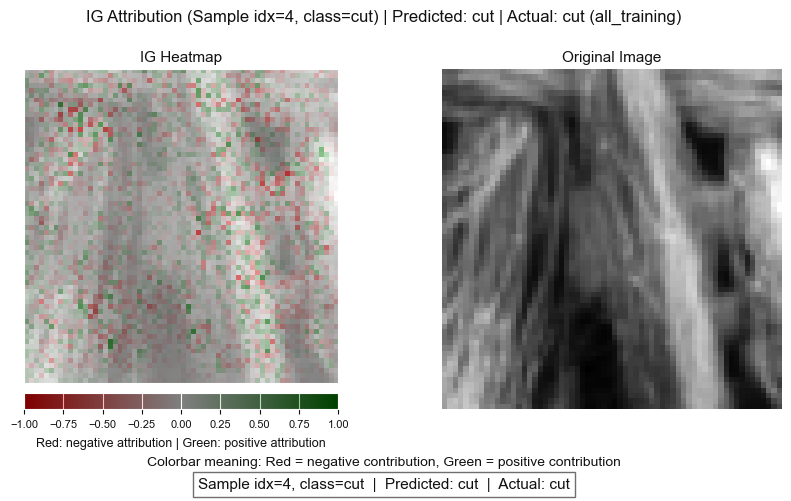

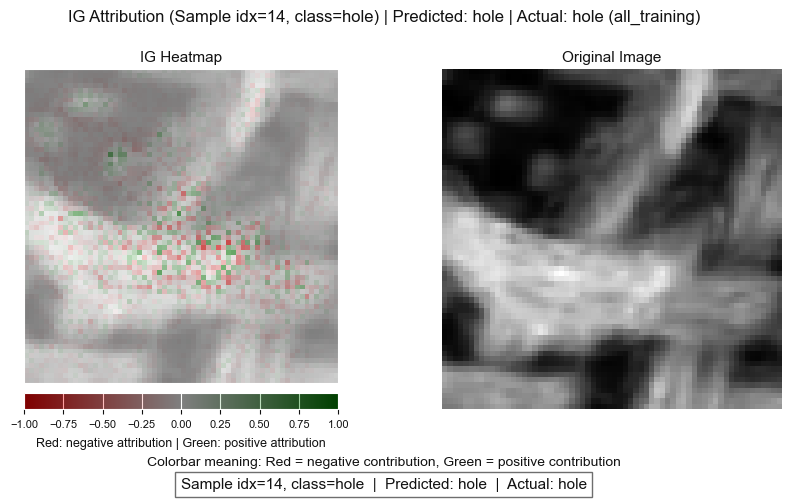

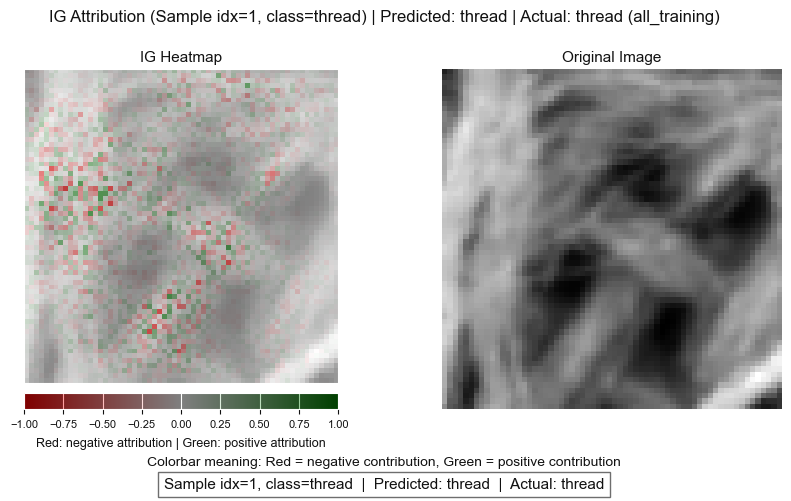

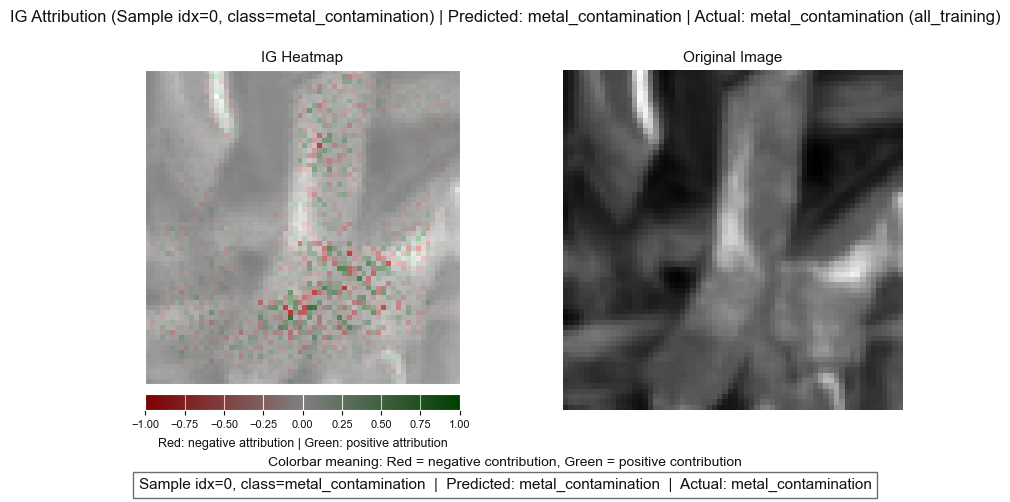

In [30]:

def apply_integrated_gradients(model, input_tensor, target_class=None):
    """
    Computes Integrated Gradients for a specific image.
    """
    if IntegratedGradients is None:
        raise ImportError("captum is not installed. Run: pip install captum")

    model.eval()
    ig = IntegratedGradients(model)

    # Baseline (a black image of the same shape)
    baseline = torch.zeros_like(input_tensor).to(device)

    if target_class is None:
        # Get the model's predicted class
        output = model(input_tensor)
        target_class = torch.argmax(output, dim=1).item()

    # Compute attributions
    attributions, _ = ig.attribute(
        input_tensor, baseline, target=target_class, return_convergence_delta=True
    )

    # Convert tensors into HWC numpy arrays robustly for grayscale/RGB.
    def _to_hwc(arr: np.ndarray) -> np.ndarray:
        # Accept [N,C,H,W], [C,H,W], [H,W,C], [H,W].
        if arr.ndim == 4:
            if arr.shape[0] != 1:
                raise ValueError(f"Expected batch size 1 for visualization, got shape={arr.shape}")
            arr = arr[0]

        if arr.ndim == 3:
            # If likely CHW, transpose to HWC.
            if arr.shape[0] <= 4 and arr.shape[1] > 4 and arr.shape[2] > 4:
                arr = np.transpose(arr, (1, 2, 0))
            # Else assume already HWC.
        elif arr.ndim == 2:
            arr = arr[..., np.newaxis]
        else:
            raise ValueError(f"Unsupported array shape for visualization: {arr.shape}")

        return arr

    attributions = _to_hwc(attributions.detach().cpu().numpy())
    img_plot = _to_hwc(input_tensor.detach().cpu().numpy())

    return attributions, img_plot, target_class


def _displayable_img(img_plot: np.ndarray):
    if img_plot.ndim == 3 and img_plot.shape[-1] == 1:
        return img_plot[..., 0], "gray"
    if img_plot.ndim == 2:
        return img_plot, "gray"
    return img_plot, None


def plot_ig_results(attributions, img_plot, predicted_class, actual_class, label_map, sample_idx=None):
    if viz is None:
        raise ImportError("captum is not installed. Run: pip install captum")

    idx_to_class = {v: k for k, v in label_map.items()}
    pred_name = idx_to_class.get(int(predicted_class), str(predicted_class))
    actual_name = idx_to_class.get(int(actual_class), str(actual_class))
    sample_text = f"Sample {sample_idx}" if sample_idx is not None else "Sample"

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    fig.patch.set_facecolor("#ffffff")

    viz.visualize_image_attr(
        attributions,
        img_plot,
        method="blended_heat_map",
        sign="all",
        show_colorbar=True,
        title="IG Heatmap",
        plt_fig_axis=(fig, axes[0]),
        use_pyplot=False,
    )
    cbar_axes = [ax for ax in fig.axes if ax not in axes]
    if cbar_axes:
        cax = cbar_axes[0]
        cax.set_xlabel("Red: negative attribution | Green: positive attribution", color="#111111", fontsize=9, labelpad=6)
        cax.tick_params(colors="#111111", labelsize=8)
    axes[0].set_title("IG Heatmap", color="#111111", fontsize=11)
    axes[0].set_aspect("equal")

    disp_img, cmap = _displayable_img(img_plot)
    axes[1].imshow(disp_img, cmap=cmap, interpolation="nearest")
    axes[1].set_title("Original Image", color="#111111", fontsize=11)
    axes[1].axis("off")
    axes[1].set_aspect("equal")
    axes[1].set_xlim(axes[0].get_xlim())
    axes[1].set_ylim(axes[0].get_ylim())

    fig.suptitle(
        f"IG Attribution ({sample_text}) | Predicted: {pred_name} | Actual: {actual_name} (all_training)",
        fontsize=12,
        color="#111111",
        y=0.98,
    )
    fig.text(
        0.5,
        0.075,
        "Colorbar meaning: Red = negative contribution, Green = positive contribution",
        ha="center",
        va="center",
        fontsize=10,
        color="#111111",
    )
    fig.text(
        0.5,
        0.03,
        f"{sample_text}  |  Predicted: {pred_name}  |  Actual: {actual_name}",
        ha="center",
        va="center",
        fontsize=11,
        color="#111111",
        bbox={"facecolor": "#ffffff", "edgecolor": "#666666", "alpha": 0.95, "pad": 4},
    )
    fig.subplots_adjust(top=0.86, bottom=0.18, wspace=0.25)
    plt.show()
    plt.close(fig)


def _defect_classes(label_map: Dict[str, int]):
    non_defect_names = {"good", "normal", "ok", "none", "no_defect", "background"}
    classes = []
    for class_name, class_id in label_map.items():
        if str(class_name).strip().lower() not in non_defect_names:
            classes.append((str(class_name), int(class_id)))
    if not classes:
        classes = [(str(class_name), int(class_id)) for class_name, class_id in label_map.items()]
    return classes


def _first_sample_index_per_class(dataset, target_class_ids):
    sample_indices = {}

    # Fast path: use dataframe labels directly to avoid loading many images from H5.
    if hasattr(dataset, "df") and hasattr(dataset, "label_map"):
        labels = dataset.df["indication_type"].astype(str).str.strip().tolist()
        for idx, class_name in enumerate(labels):
            label_id = int(dataset.label_map[class_name])
            if label_id in target_class_ids and label_id not in sample_indices:
                sample_indices[label_id] = idx
                if len(sample_indices) == len(target_class_ids):
                    break
        return sample_indices

    # Fallback path
    for idx in range(len(dataset)):
        _, label = dataset[idx]
        label_id = int(label.item()) if torch.is_tensor(label) else int(label)
        if label_id in target_class_ids and label_id not in sample_indices:
            sample_indices[label_id] = idx
            if len(sample_indices) == len(target_class_ids):
                break
    return sample_indices


# Auto-run IG visualizations: one sample per defect class.
if IntegratedGradients is None or viz is None:
    print("[INFO] captum is not installed. Skipping IG demo plot.")
elif {"model_resnet", "train_ds", "train_label_map", "device"}.issubset(globals()) and len(train_ds) > 0:
    try:
        defect_classes = _defect_classes(train_label_map)
        target_class_ids = {class_id for _, class_id in defect_classes}
        sample_indices = _first_sample_index_per_class(train_ds, target_class_ids)

        if not sample_indices:
            print("[WARN] No class samples found for IG visualization.")
        else:
            for class_name, class_id in defect_classes:
                if class_id not in sample_indices:
                    print(f"[WARN] No sample found for class '{class_name}' (id={class_id}).")
                    continue

                ds_idx = sample_indices[class_id]
                sample_img, true_label = train_ds[ds_idx]
                input_tensor = sample_img.unsqueeze(0).to(device)
                attrs, img_plot, pred_cls = apply_integrated_gradients(model_resnet, input_tensor)
                true_cls = int(true_label.item()) if torch.is_tensor(true_label) else int(true_label)
                plot_ig_results(
                    attrs,
                    img_plot,
                    pred_cls,
                    true_cls,
                    train_label_map,
                    sample_idx=f"idx={ds_idx}, class={class_name}",
                )
    except Exception as e:
        print(f"[WARN] IG demo skipped due to error: {e}")
else:
    print("[INFO] IG prerequisites not ready. Run ResNet training cell first.")
